# Module 6 - Alzheimer's Drug Suite: Cohort & Class Definition

Same shape as `module_1_fluorouracil/01_5fu_explore.ipynb`. Defines the cohort and drug-class mapping used by every downstream notebook in this module.

**Drug classes covered:**
- **Cholinesterase inhibitors (ChEIs)**: donepezil, rivastigmine, galantamine
- **NMDA receptor antagonist**: memantine
- **Anti-amyloid biologics**: lecanemab, aducanumab, donanemab

The last group is small (~55 reports in FAERS 2024 so far, mostly lecanemab). Included for class-comparison completeness, but statistical analyses on that group will have wide CIs.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

## Step 1 - Which drugname strings exist for each class?

In [2]:
# Show every distinct drugname matching the Alzheimer's class patterns.
# The output confirms brand-name / formulation variants we need to collapse.

drug_variants = pd.read_sql_query("""
SELECT DISTINCT drugname,
       COUNT(DISTINCT primaryid) AS reports
FROM drug
WHERE  drugname LIKE '%DONEPEZIL%'
    OR drugname LIKE '%RIVASTIGMINE%'
    OR drugname LIKE '%GALANTAMINE%'
    OR drugname LIKE '%MEMANTINE%'
    OR drugname LIKE '%LECANEMAB%'
    OR drugname LIKE '%ADUCANUMAB%'
    OR drugname LIKE '%DONANEMAB%'
GROUP BY drugname
HAVING reports >= 5
ORDER BY reports DESC
""", conn)

print(f'{len(drug_variants)} drugname strings with >= 5 reports')
drug_variants.head(30)

14 drugname strings with >= 5 reports


,drugname,reports
0,DONEPEZIL,1841
1,MEMANTINE,1588
2,RIVASTIGMINE,1104
3,DONEPEZIL HYDROCHLORIDE,792
4,MEMANTINE HYDROCHLORIDE,261
5,GALANTAMINE,182
6,GALANTAMINE HYDROBROMIDE,128
7,RIVASTIGMINE TARTRATE,44
8,LECANEMAB,40
9,RIVASTIGMINE TRANSDERMAL SYSTEM,25


## Step 2 - Build a class-labeled cohort table

In [3]:
# Assign a canonical drug_class label per (primaryid, drugname).
# Restricted to PS / SS role_cod (primary / secondary suspect), which is the
# defensible cohort for signal-detection work.
# Saved as an SQLite table so downstream notebooks can just JOIN on it.

conn.execute('DROP TABLE IF EXISTS alzheimers_analysis')
conn.execute("""
CREATE TABLE alzheimers_analysis AS
SELECT DISTINCT
    primaryid,
    caseid,
    drugname,
    role_cod,
    CASE
        WHEN drugname LIKE '%DONEPEZIL%'
          OR drugname LIKE '%RIVASTIGMINE%'
          OR drugname LIKE '%GALANTAMINE%' THEN 'ChEI'
        WHEN drugname LIKE '%MEMANTINE%'   THEN 'NMDA'
        WHEN drugname LIKE '%LECANEMAB%'
          OR drugname LIKE '%ADUCANUMAB%'
          OR drugname LIKE '%DONANEMAB%'   THEN 'Anti-amyloid'
    END AS drug_class
FROM drug
WHERE role_cod IN ('PS', 'SS')
  AND (drugname LIKE '%DONEPEZIL%'
       OR drugname LIKE '%RIVASTIGMINE%'
       OR drugname LIKE '%GALANTAMINE%'
       OR drugname LIKE '%MEMANTINE%'
       OR drugname LIKE '%LECANEMAB%'
       OR drugname LIKE '%ADUCANUMAB%'
       OR drugname LIKE '%DONANEMAB%')
""")
conn.commit()

summary = pd.read_sql_query("""
    SELECT drug_class,
           COUNT(DISTINCT primaryid) AS reports
    FROM alzheimers_analysis
    GROUP BY drug_class
    ORDER BY reports DESC
""", conn)
summary

,drug_class,reports
0,ChEI,1297
1,NMDA,449
2,Anti-amyloid,47


## Step 3 - Report counts per class + per quarter

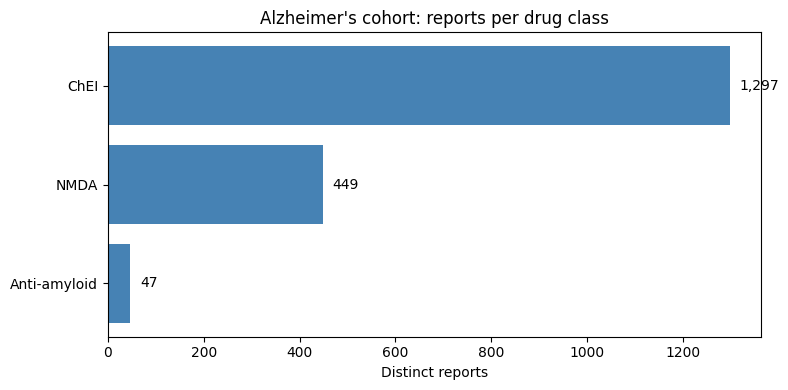

In [4]:
# Bar chart of report count per drug class.

plt.figure(figsize=(8, 4))
plt.barh(summary['drug_class'], summary['reports'], color='steelblue')
plt.gca().invert_yaxis()
for i, v in enumerate(summary['reports']):
    plt.text(v + 20, i, f'{v:,}', va='center')
plt.xlabel('Distinct reports')
plt.title('Alzheimer\'s cohort: reports per drug class')
plt.tight_layout()
plt.show()

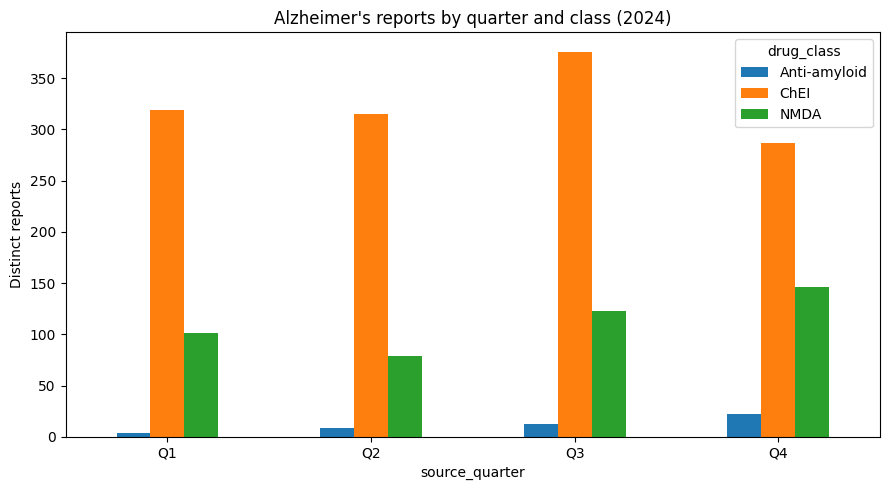

drug_class,Anti-amyloid,ChEI,NMDA
source_quarter,,,
Q1,4,319,101
Q2,9,315,79
Q3,12,376,123
Q4,22,287,146


In [5]:
# Quarterly cadence per class (2024 Q1-Q4).

qtr = pd.read_sql_query("""
    SELECT a.drug_class,
           d.source_quarter,
           COUNT(DISTINCT a.primaryid) AS reports
    FROM alzheimers_analysis a
    JOIN demo d ON d.primaryid = a.primaryid
    WHERE d.source_quarter IS NOT NULL
    GROUP BY a.drug_class, d.source_quarter
    ORDER BY d.source_quarter
""", conn)

pivot = qtr.pivot(index='source_quarter', columns='drug_class', values='reports').fillna(0)
pivot.plot(kind='bar', figsize=(9, 5))
plt.ylabel('Distinct reports')
plt.title('Alzheimer\'s reports by quarter and class (2024)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pivot